In [2]:
import numpy as np
import matplotlib.pyplot as plt

## **Hospital Overflow + Unmet Care Simulation and Analysis**

This is essentially just a crude model with some simulations and subsequent analysis of hospital overflow and unmet care needs over a specified period. It models patient arrivals, hospital capacity, and the resulting overflow and unmet care statistics, we can modify this in many ways if we want.

- I kind of need to triple check but I feel like this covers most of the things that Dr. Larremore was saying in his feedback.

- The implementation sets up a SIXHRD compartmental model with hospital capacity contraints.

- It uses Euler's method to simulate the system with a time step of ```dt``` over a period of ```Tmax``` days.

- It implements the smooth Hill function for modeling hospital admission gating.

- It tracks key metrics such as total overflow and unmet care needs.

- It includes vaccine effects using a leaky model when coverage $\gt 0$.
- It visualizes the results of the epidemic dynamics, hospital capacity utilization, overflow, and summary statistics.

## **The breakdown:**

- **S**: Susceptible
- **I**: Infected, "uncomplicated cases" (mild or early in disease perhaps)
- **X**: Severe cases who NEED to go to the hospital for care
- **H**: Hospitalized (subset of X who successfully get admitted)
- **R**: Recovered
- **D**: Dead

**Key parameters**:
- `beta`: Transmission rate
- `theta_X`, `theta_H`: Relative infectiousness of X and H compartments vs I
- `sigma`: Rate that I people move into X (severe cases)
- `gamma_I`,`gamma_X`, `gamma_H`: Recovery rates for I, X, and H compartments
- `mu_I`,`mu_X`, `mu_H`: Mortality rates for I, X, and H compartments
- `hosp_capacity = K`: Maximum hospital capacity (number of beds)
- `hill_coef = n`: How sharply the hospital admissions are throttled as H approaches K
- `coverage`, `VE`: Vaccine coverage and vaccine efficacy (leaky model)

## **Force of Infection**

$$\lambda = \beta_{eff} \frac{I + \theta_X X + \theta_H H}{N}$$

Where $\beta_{eff} = \beta (1 - coverage * VE)$

and new infections `new_inf` = $\lambda * S$

So the vaccine acts on $\beta$ and doesn't block infection completely.

## **Hospital capacity gate**

This implementation is using a smooth "Hill function" to model gating of hospital admissions:

$$g(H) = \frac{1}{1 + (\frac{H}{K})^n}$$

then

$$admissions = \sigma * X * g(H)$$

- When $H \ll K, g \approx 1$: almost everyone in X who should be admitted is admitted.
- When $H \gg K, g \rightarrow 0$: very few admissions occur as the hospital is at or beyond capacity. Unmet need is driven upwards.
- At $H = K, g = \frac{1}{2}$: admissions are cut in half when hospital is at capacity.

This is a soft capacity constraint, meaning that admissions don't just stop when capacity is reached, but are slowed down smoothly and with more realism.

## **The ODEs:**


\begin{aligned}
\frac{dS}{dt} &= -\text{new\_inf} \\
\frac{dI}{dt} &= \text{new\_inf} - (\gamma_I + \mu_I + \sigma) I \\
\frac{dX}{dt} &= \sigma I - (\gamma_X + \mu_X) X - \text{admit} \\
\frac{dH}{dt} &= \text{admit} - (\gamma_H + \mu_H) H \\
\frac{dR}{dt} &= \gamma_I I + \gamma_X X + \gamma_H H \\
\frac{dD}{dt} &= \mu_I I + \mu_X X + \mu_H H
\end{aligned}

- So people leave $I$ either by recovering, dying, or progressing into severe cases $X$.
- People in $X$ can either recover, die, or get admitted to the hospital $H$ (if capacity allows).
- People in $H$ can recover or die.
- $R$ and $D$ collect all the outflows from the other compartments.


## **Metrics being tracked in the model:**

- `overflow = max(0, H - K)`: This is how many patients are in the hospital beyond capacity at each time step.
- `cumulative_overflow`: Total burden of overflow on the system over a single simulation run.
- `unmet_care = eta * X - admit`: People in X who need care but aren't because of capacity limits.
- `cumulative_unmet`: Total unmet care needs over the simulation period. 

# The Hospital Overflow Model **SIXHRD**

In [3]:
def simulate_hospital_model(beta, sigma, eta, gamma_I, mu_I, gamma_X, mu_X, 
                           gamma_H, mu_H, theta_X, theta_H, hosp_capacity, 
                           hill_coef, coverage, VE, N, S=None, I=None, X=None, 
                           H=None, R=None, D=None, Tmax=200, time_step=0.1):
    """
    Simulate SIXHRD hospital model with capacity constraints.
    """
    K = hosp_capacity
    n = hill_coef
    dt = time_step
    
    # Initial conditions - use parameters if provided, else defaults
    if S is None:
        S = N - 10
    if I is None:
        I = 10
    if X is None:
        X = 0
    if H is None:
        H = 0
    if R is None:
        R = 0
    if D is None:
        D = 0
    
    # storage arrays
    times = []
    S_vals, I_vals, X_vals, H_vals, R_vals, D_vals = [], [], [], [], [], []
    overflow_vals = []
    unmet_vals = []
    cum_overflow = 0
    cum_unmet = 0
    
    # vaccine effect
    eff_beta = beta * (1 - coverage * VE)
    
    # loop across time
    t = 0
    while t <= Tmax:
        # store values at each time step
        times.append(t)
        S_vals.append(S)
        I_vals.append(I)
        X_vals.append(X)
        H_vals.append(H)
        R_vals.append(R)
        D_vals.append(D)
        
        # Force of infection
        lambda_foi = eff_beta * (I + theta_X*X + theta_H*H) / N
        new_inf = lambda_foi * S
        
        # Capacity gate (smooth Hill function)
        if K > 0:
            g = 1 / (1 + (H/K)**n)
        else:
            g = 0
        admit = eta * X * g
        
        # The ODEs
        dS = -new_inf
        dI = new_inf - (gamma_I + mu_I + sigma) * I
        dX = sigma*I - (gamma_X + mu_X) * X - admit
        dH = admit - (gamma_H + mu_H) * H
        dR = gamma_I*I + gamma_X*X + gamma_H*H
        dD = mu_I*I + mu_X*X + mu_H*H
        
        # Euler update
        S += dS * dt
        I += dI * dt
        X += dX * dt
        H += dH * dt
        R += dR * dt
        D += dD * dt
        
        # Prevent negative values
        S = max(0, S)
        I = max(0, I)
        X = max(0, X)
        H = max(0, H)
        R = max(0, R)
        D = max(0, D)
        
        # Track metrics
        overflow = max(0, H - K)
        cum_overflow += overflow * dt
        overflow_vals.append(overflow)
        
        unmet_care = eta*X - admit
        unmet_vals.append(unmet_care)
        cum_unmet += max(0, unmet_care) * dt
        
        t += dt
        
    return times, S_vals, I_vals, X_vals, H_vals, R_vals, D_vals, overflow_vals, cum_overflow, cum_unmet, unmet_vals

# Plotting Functionality:

In [4]:
def plot_hospital_simulation_stats(times, S_vals, I_vals, X_vals, H_vals, R_vals, 
                                   D_vals, overflow_vals, cum_overflow, cum_unmet, 
                                   hosp_capacity, N):
    """Plot simulation results."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Compartments over time
    axes[0, 0].plot(times, S_vals, label='S (Susceptible)')
    axes[0, 0].plot(times, I_vals, label='I (Infected)')
    axes[0, 0].plot(times, X_vals, label='X (Needs care)')
    axes[0, 0].plot(times, H_vals, label='H (Hospitalized)')
    axes[0, 0].plot(times, R_vals, label='R (Recovered)')
    axes[0, 0].plot(times, D_vals, label='D (Deaths)')
    axes[0, 0].set_xlabel('Time (days)')
    axes[0, 0].set_ylabel('Population')
    axes[0, 0].legend()
    axes[0, 0].set_title('Epidemic Dynamics')
    axes[0, 0].grid(True, alpha=0.3)

    # Hospital capacity
    axes[0, 1].plot(times, H_vals, label='Hospitalized', color='red')
    axes[0, 1].axhline(y=hosp_capacity, color='black', linestyle='--', 
                       label=f'Capacity (K={hosp_capacity})')
    axes[0, 1].fill_between(times, 0, hosp_capacity, alpha=0.2, 
                            color='green', label='Available capacity')
    axes[0, 1].set_xlabel('Time (days)')
    axes[0, 1].set_ylabel('Hospital beds')
    axes[0, 1].legend()
    axes[0, 1].set_title('Hospital Capacity Utilization')
    axes[0, 1].grid(True, alpha=0.3)

    # Overflow
    axes[1, 0].plot(times, overflow_vals, color='red')
    axes[1, 0].set_xlabel('Time (days)')
    axes[1, 0].set_ylabel('Overflow patients')
    axes[1, 0].set_title(f'Hospital Overflow (Cumulative: {cum_overflow:.1f} patient-days)')
    axes[1, 0].grid(True, alpha=0.3)

    # Summary statistics
    axes[1, 1].axis('off')
    attack_rate = (R_vals[-1] + D_vals[-1]) / N * 100
    summary_text = f"""
  Summary Statistics:
  ━━━━━━━━━━━━━━━━━━━━━━
  Peak Hospitalized: {max(H_vals):.1f}
  Total Deaths: {D_vals[-1]:.1f}
  Total Recovered: {R_vals[-1]:.1f}
  Attack Rate: {attack_rate:.1f}%

  Cumulative Overflow: {cum_overflow:.1f} patient-days
  Cumulative Unmet Care: {cum_unmet:.1f} patient-days

  Final Population:
    S: {S_vals[-1]:.1f}
    I: {I_vals[-1]:.1f}
    X: {X_vals[-1]:.1f}
    H: {H_vals[-1]:.1f}
    R: {R_vals[-1]:.1f}
    D: {D_vals[-1]:.1f}
  """

    axes[1, 1].text(0.1, 0.5, summary_text, fontsize=11, family='monospace', 
                    verticalalignment='center')

    plt.tight_layout()
    plt.show()

    print(f"\nSimulation complete!")
    print(f"Total deaths: {D_vals[-1]:.0f}")
    print(f"Peak hospital occupancy: {max(H_vals):.1f} (Capacity: {hosp_capacity})")
    print(f"Cumulative overflow: {cum_overflow:.1f} patient-days")
    print(f"Cumulative unmet care: {cum_unmet:.1f} patient-days")

# Here we simulate over values of Beta and observe hospital overflow and unmet care needs.

In [20]:
peak_occupancies = []
cumulative_overflows = []
final_death_counts = []
beta_vals = [0.1,0.125,0.15,0.175,0.2,0.225,0.25,0.275,0.3, 0.325,0.35,0.375,0.4,0.425,0.45,0.475,0.5,0.525, 0.55,0.575, 0.6,0.625, 0.65,0.675, 0.7,0.725,0.75,0.775,0.8,0.825,0.85,0.875,0.9]

for beta in beta_vals:
    times, S_vals, I_vals, X_vals, H_vals, R_vals, D_vals, overflow_vals, cumulative_overflow, cumulative_unmet, unmet_care = simulate_hospital_model(
        beta=beta,
        sigma=0.2,
        eta=0.3,
        gamma_I=0.1,
        mu_I=0.01,
        gamma_X=0.15,
        mu_X=0.05,
        gamma_H=0.2,
        mu_H=0.02,
        theta_X=0.5,
        theta_H=0.3,
        hosp_capacity=100,
        hill_coef=4,
        coverage=0.1,
        VE=0.7,
        N=10000,
        S=None,
        I=None,
        X=None,
        H=None,
        R=None,
        D=None,
        Tmax=200,
        time_step=0.1
    )
    
    peak_occupancies.append(max(H_vals))
    final_death_counts.append(D_vals[-1])
    cumulative_overflows.append(cumulative_overflow) 
    
    # plot_hospital_simulation_stats(times, S_vals, I_vals, X_vals, H_vals, R_vals, D_vals, overflow_vals, cumulative_overflow, cumulative_unmet, hosp_capacity=100, N = 10000)
    
    
    print(f"\nBeta: {beta}")
    print(f"Total deaths: {D_vals[-1]:.0f}")
    print(f"Peak hospital occupancy: {max(H_vals):.1f} (Capacity: 100)")
    print(f"Cumulative overflow: {cumulative_overflow:.1f} patient-days")


Beta: 0.1
Total deaths: 2
Peak hospital occupancy: 1.9 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.125
Total deaths: 3
Peak hospital occupancy: 2.1 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.15
Total deaths: 3
Peak hospital occupancy: 2.3 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.175
Total deaths: 5
Peak hospital occupancy: 2.5 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.2
Total deaths: 7
Peak hospital occupancy: 2.8 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.225
Total deaths: 15
Peak hospital occupancy: 3.3 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.25
Total deaths: 67
Peak hospital occupancy: 5.0 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.275
Total deaths: 270
Peak hospital occupancy: 29.7 (Capacity: 100)
Cumulative overflow: 0.0 patient-days

Beta: 0.3
Total deaths: 478
Peak hospital occupancy: 71.9 (Capacity: 100)
Cumulative overflow: 0.0 patie

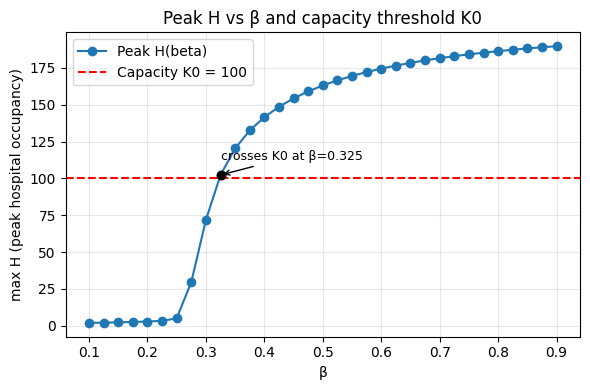

In [ ]:
K0 = 100  # capacity threshold

plt.figure(figsize=(6, 4))
plt.plot(beta_vals, peak_occupancies, marker='o', label='Peak H(beta)')
plt.axhline(K0, color='red', linestyle='--', label=f'Capacity K0 = {K0}')

# find first beta where peak H crosses K0
cross_beta = None
for b, h in zip(beta_vals, peak_occupancies):
    if h >= K0:
        cross_beta = b
        break

if cross_beta is not None:
    # mark the crossing point
    cross_H = peak_occupancies[beta_vals.index(cross_beta)]
    plt.scatter([cross_beta], [cross_H], color='black', zorder=5)
    plt.annotate(f'crosses K0 at β={cross_beta}',
                 xy=(cross_beta, cross_H),
                 xytext=(cross_beta, cross_H * 1.1),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9)

plt.xlabel('β')
plt.ylabel('max H (peak hospital occupancy)')
plt.title('Peak H vs β and capacity threshold K0')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# How does hospital capacity $K$ affect deaths and overflow for a given $\beta$?

- Fixing all other parameters and $\beta$,
- Sweeping over `hosp_capacity` values
- For each K, simulate and record:
    - Total deaths at end of simulation
    - Cumulative overflow
    - Cumulative unmet care needs


Hospital Capacity: 25
Total deaths: 1554
Peak hospital occupancy: 56.4 (Capacity: 25)
Cumulative overflow: 947.1 patient-days

Hospital Capacity: 50
Total deaths: 1495
Peak hospital occupancy: 96.5 (Capacity: 50)
Cumulative overflow: 1210.8 patient-days

Hospital Capacity: 75
Total deaths: 1448
Peak hospital occupancy: 131.5 (Capacity: 75)
Cumulative overflow: 1314.7 patient-days

Hospital Capacity: 100
Total deaths: 1409
Peak hospital occupancy: 163.1 (Capacity: 100)
Cumulative overflow: 1333.4 patient-days

Hospital Capacity: 125
Total deaths: 1375
Peak hospital occupancy: 192.2 (Capacity: 125)
Cumulative overflow: 1298.9 patient-days

Hospital Capacity: 150
Total deaths: 1345
Peak hospital occupancy: 219.2 (Capacity: 150)
Cumulative overflow: 1228.3 patient-days

Hospital Capacity: 175
Total deaths: 1319
Peak hospital occupancy: 244.4 (Capacity: 175)
Cumulative overflow: 1133.0 patient-days

Hospital Capacity: 200
Total deaths: 1295
Peak hospital occupancy: 268.1 (Capacity: 200)
Cu

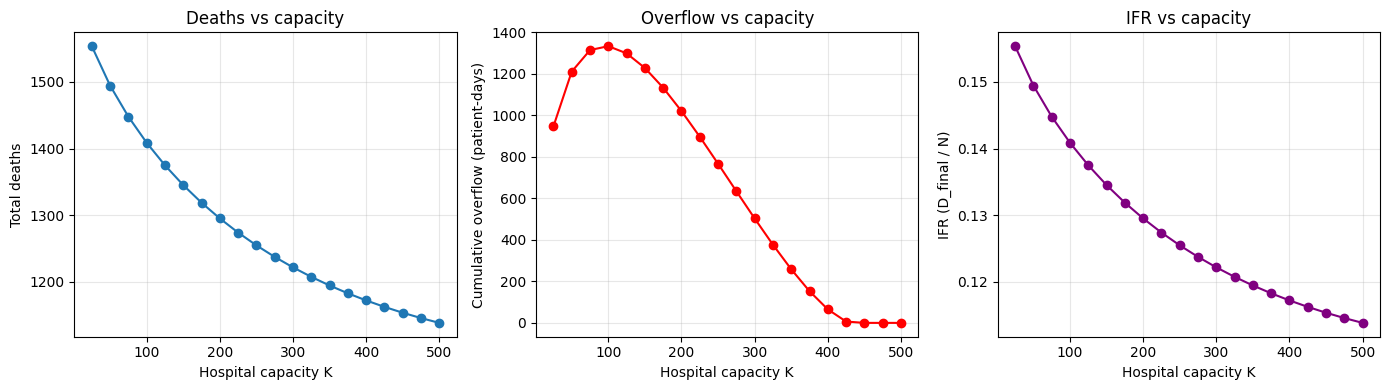

In [24]:
K_vals = [25, 50, 75, 100,125, 150, 175, 200,225, 250, 275, 300, 325, 350,375, 400,425, 450, 475, 500]

deaths_vs_K = []
overflow_vs_K = []
ifr_vs_K = []

for K in K_vals:
    times, S_vals, I_vals, X_vals, H_vals, R_vals, D_vals, overflow_vals, cumulative_overflow, cumulative_unmet, unmet_care = simulate_hospital_model(
        beta=0.5,
        sigma=0.2,
        eta=0.3,
        gamma_I=0.1,
        mu_I=0.01,
        gamma_X=0.15,
        mu_X=0.05,
        gamma_H=0.2,
        mu_H=0.02,
        theta_X=0.5,
        theta_H=0.3,
        hosp_capacity=K,
        hill_coef=4,
        coverage=0.1,
        VE=0.7,
        N=10000,
        S=None,
        I=None,
        X=None,
        H=None,
        R=None,
        D=None,
        Tmax=200,
        time_step=0.1
    )
    
    final_deaths = D_vals[-1]
    deaths_vs_K.append(final_deaths)
    overflow_vs_K.append(cumulative_overflow)
    ifr_vs_K.append(final_deaths / 10000)  # IFR = D_final / N
    
    # plot_hospital_simulation_stats(times, S_vals, I_vals, X_vals, H_vals, R_vals, D_vals, overflow_vals, cumulative_overflow, cumulative_unmet, hosp_capacity=100, N = 10000)
    
    print(f"\nHospital Capacity: {K}")
    print(f"Total deaths: {D_vals[-1]:.0f}")
    print(f"Peak hospital occupancy: {max(H_vals):.1f} (Capacity: {K})")
    print(f"Cumulative overflow: {cumulative_overflow:.1f} patient-days")
    
    # Now plot how outcomes change with capacity
plt.figure(figsize=(14, 4))

# Deaths vs capacity
plt.subplot(1, 3, 1)
plt.plot(K_vals, deaths_vs_K, marker='o')
plt.xlabel('Hospital capacity K')
plt.ylabel('Total deaths')
plt.title('Deaths vs capacity')
plt.grid(True, alpha=0.3)

# Cumulative overflow vs capacity
plt.subplot(1, 3, 2)
plt.plot(K_vals, overflow_vs_K, marker='o', color='red')
plt.xlabel('Hospital capacity K')
plt.ylabel('Cumulative overflow (patient-days)')
plt.title('Overflow vs capacity')
plt.grid(True, alpha=0.3)

# IFR vs capacity
plt.subplot(1, 3, 3)
plt.plot(K_vals, ifr_vs_K, marker='o', color='purple')
plt.xlabel('Hospital capacity K')
plt.ylabel('IFR (D_final / N)')
plt.title('IFR vs capacity')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
